In [1]:
import pandas as pd
import numpy as np
Patients = pd.read_csv('patients.csv')
Diagnosis = pd.read_csv('diagnoses.csv')
Labs = pd.read_csv('labs.csv')
Outcomes = pd.read_csv('outcomes.csv')


In [2]:
Patients = Patients.merge(Diagnosis, on ='DiagnosisID')
Patients = Patients.merge(Outcomes, on ='OutcomeID')


In [3]:
Patients['AdmissionDate'] = pd.to_datetime(Patients['AdmissionDate'])
Patients['DischargeDate'] = pd.to_datetime(Patients['DischargeDate'])
Patients['Lengthofstay'] = (Patients['DischargeDate'] - Patients['AdmissionDate']).dt.days

In [4]:
Patients['OutcomeEmcoded'] = Patients['OutcomeName'].map({'Recovered' : 0, 'Complicated' : 1, 'Deceased' : 1})

In [5]:
Patients['Highrisk'] = np.where((Patients['Age']>65) | (Patients['OutcomeName'].isin(['Complicated', 'Deceased'])), 1, 0)

In [6]:
abnormal_conditions = {
    'Blood Sugar': lambda x: x>120,
    'Cholestrol': lambda x: x>200,
    'Hemoglobin': lambda x:x<13
}

def count_abnormal_labs(Patient_id):
    Patients_labs = Labs[Labs['PatientID'] == Patient_id]
    count = 0
    for test_name, condition in abnormal_conditions.items():
        test_results = Patients_labs[Patients_labs['TestName'] == test_name]
        count += test_results['Result'].apply(condition).sum()
    return count

Patients['Abnormallabcount'] = Patients['PatientID'].apply(count_abnormal_labs)

Model Training

In [15]:
features = Patients[['Age', 'Lengthofstay', 'TreatmentCost']]
target = Patients['OutcomeEmcoded']

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
print("classification_report: ")
print(classification_report(y_test, y_pred))

classification_report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.36      0.50      0.42        60
weighted avg       0.51      0.72      0.60        60



d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Roc curve

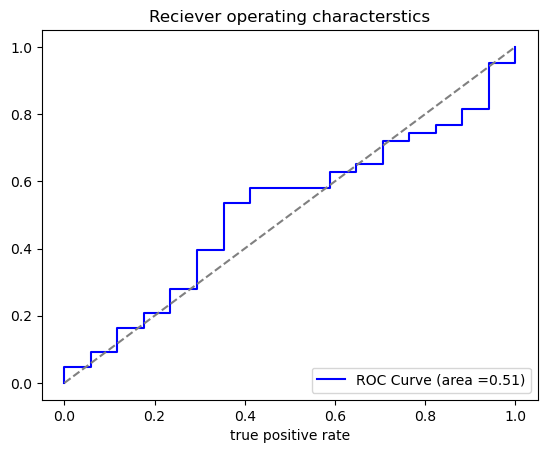

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color ='blue', label= f'ROC Curve (area ={roc_auc:.2f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--')
plt.xlabel('false positive rate')
plt.xlabel('true positive rate')
plt.title('Reciever operating characterstics')
plt.legend(loc="lower right")
plt.show()

In [12]:
import joblib
joblib.dump(model, 'riskmanagement.ipynb')

['riskmanagement.ipynb']

In [13]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [14]:
import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

model = RandomForestClassifier(random_state=42)
model.fit(features, target)

joblib.dump(model, "riskmanagement.pkl")
st.title("Health Risk Stratisfication App")
age = st.number_input("Age",min_value=0)
length_of_stay = st.number_input("Length of stay(days)", min_value=0)
treatment_cost = st.number_input("Treatment Cost",min_value=0.0)

if st.button("Predict"):
    input_data = pd.DataFrame([[age, length_of_stay,treatment_cost]], columns=['Age','Lengthofstay','TreatmentCost'])
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.write(f"Risk Prediction: {'High Risk' if prediction ==1 else 'Low Risk'}")
    st.write(f"Risk Probability: {round(probability,2)}")







2026-07-23 00:38:59.230 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.922 
  command:

    streamlit run d:\anaconda2\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-23 00:39:02.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 00:39:02.942 Thread 'MainThread': missing Script